# Module 2 – EDA Part 1: Sampled Datasets

We have data from a groceries e-commerce platform (think online supermarket).  
The data is split across 5 datasets:

| Dataset | What it contains |
|---|---|
| `orders.parquet` | History of customer orders |
| `regulars.parquet` | Items users have set as "buy regularly" |
| `abandoned_carts.parquet` | Items added to basket but never bought |
| `inventory.parquet` | Info about each product |
| `users.parquet` | Info about each user |

**Goal of this first section:** load the data and understand its basic structure before doing any analysis.


## 0. Setup


In [ ]:
import pandas as pd
from pathlib import Path

# Path to the locally downloaded data
DATA_DIR = Path("../data/module_2/sampled-datasets")

# Display options: show all columns and limit decimal places
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)


## 1. Loading the data

We load all 5 datasets. They are in **parquet** format, which is a columnar binary format — much more efficient than CSV for large datasets (smaller size, faster reads, preserves data types automatically).


In [ ]:
orders = pd.read_parquet(DATA_DIR / "orders.parquet")
regulars = pd.read_parquet(DATA_DIR / "regulars.parquet")
abandoned_carts = pd.read_parquet(DATA_DIR / "abandoned_carts.parquet")
inventory = pd.read_parquet(DATA_DIR / "inventory.parquet")
users = pd.read_parquet(DATA_DIR / "users.parquet")

datasets = {
    "orders": orders,
    "regulars": regulars,
    "abandoned_carts": abandoned_carts,
    "inventory": inventory,
    "users": users,
}

print("All datasets loaded successfully")


All datasets loaded successfully


## 2. First look: shape and column types

Before anything else, we want to know:
- **How many rows and columns** does each dataset have?
- **What type is each column?** (number, text, date, list...)

This tells us the scale of the data and gives us a first idea of what we're working with.


In [ ]:
for name, df in datasets.items():
    print(f"{'='*50}")
    print(f" {name.upper()}")
    print(f"{'='*50}")
    print(f"  Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print()
    print(df.dtypes.to_string())
    print()


 ORDERS
  Shape: 8,773 rows x 6 columns

id                         int64
user_id                   object
created_at        datetime64[us]
order_date        datetime64[us]
user_order_seq             int64
ordered_items             object

 REGULARS
  Shape: 18,105 rows x 3 columns

user_id               object
variant_id             int64
created_at    datetime64[us]

 ABANDONED_CARTS
  Shape: 5,457 rows x 4 columns

id                     int64
user_id               object
created_at    datetime64[us]
variant_id            object

 INVENTORY
  Shape: 1,733 rows x 6 columns

variant_id            int64
price               float64
compare_at_price    float64
vendor               object
product_type         object
tags                 object

 USERS
  Shape: 4,983 rows x 10 columns

user_id                   object
user_segment              object
user_nuts1                object
first_ordered_at          object
customer_cohort_month     object
count_people             float64
count_adu

## 3. Sample rows

Now let's actually **look at the data**. We print the first few rows of each dataset to understand what the values look like in practice.


In [ ]:
for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f" {name.upper()} — first 3 rows")
    print(f"{'='*50}")
    display(df.head(3))



 ORDERS — first 3 rows


,id,user_id,created_at,order_date,user_order_seq,ordered_items
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,"[33618849693828, 33618860179588, 3361887404045..."
20,2204707520644,bf591c887c46d5d3513142b6a855dd7ffb9cc00697f6f5...,2020-04-30 17:39:00,2020-04-30,1,"[33618835243140, 33618835964036, 3361886244058..."
21,2204838822020,329f08c66abb51f8c0b8a9526670da2d94c0c6eef06700...,2020-04-30 18:12:30,2020-04-30,1,"[33618891145348, 33618893570180, 3361889766618..."



 REGULARS — first 3 rows


,user_id,variant_id,created_at
3,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,33618848088196,2020-04-30 15:07:03
11,aed88fc0b004270a62ff1fe4b94141f6b1db1496dbb0c0...,33667178659972,2020-05-05 23:34:35
18,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,33619009208452,2020-04-30 15:07:03



 ABANDONED_CARTS — first 3 rows


,id,user_id,created_at,variant_id
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,"[33826459287684, 33826457616516, 3366719212762..."
13,20352449839236,9d6187545c005d39e44d0456d87790db18611d7c7379bd...,2021-06-27 05:24:13,"[34415988179076, 34037940158596, 3450282236326..."
45,20478401413252,e83fb0273d70c37a2968fee107113698fd4f389c442c0b...,2021-07-18 08:23:49,"[34543001337988, 34037939372164, 3411360609088..."



 INVENTORY — first 3 rows


,variant_id,price,compare_at_price,vendor,product_type,tags
0,39587297165444,3.09,3.15,heinz,condiments-dressings,"[table-sauces, vegan]"
1,34370361229444,4.99,5.50,whogivesacrap,toilet-roll-kitchen-roll-tissue,"[b-corp, eco, toilet-rolls]"
2,34284951863428,3.69,3.99,plenty,toilet-roll-kitchen-roll-tissue,[kitchen-roll]



 USERS — first 3 rows


,user_id,user_segment,user_nuts1,first_ordered_at,customer_cohort_month,count_people,count_adults,count_children,count_babies,count_pets
2160,0e823a42e107461379e5b5613b7aa00537a72e1b0eaa7a...,Top Up,UKH,2021-05-08 13:33:49,2021-05-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1123,15768ced9bed648f745a7aa566a8895f7a73b9a47c1d4f...,Top Up,UKJ,2021-11-17 16:30:20,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1958,33e0cb6eacea0775e34adbaa2c1dec16b9d6484e6b9324...,Top Up,UKD,2022-03-09 23:12:25,2022-03-01 00:00:00,NaN,NaN,NaN,NaN,NaN


In [ ]:
#los user_id están hasheados 
#Muchos NAs en columnas de hogar de USERS: no rellenan campos o se ha introducido el campo hace poco.

## 4. Missing values

For each dataset we check: how many null values per column, and what % of the total rows they represent.  
A high % of nulls in a column forces us to decide: drop it, impute it, or treat the null as information itself.


In [5]:
for name, df in datasets.items():
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df) * 100).round(1)
    summary = pd.DataFrame({"null_count": null_counts, "null_%": null_pct})
    summary = summary[summary["null_count"] > 0]  # only show columns with nulls

    print(f"{'='*45}")
    print(f" {name.upper()}  ({len(df):,} rows)")
    print(f"{'='*45}")
    if summary.empty:
        print("  No missing values ✓")
    else:
        print(summary.to_string())
    print()


 ORDERS  (8,773 rows)
  No missing values ✓

 REGULARS  (18,105 rows)
  No missing values ✓

 ABANDONED_CARTS  (5,457 rows)
  No missing values ✓

 INVENTORY  (1,733 rows)
  No missing values ✓

 USERS  (4,983 rows)
                null_count  null_%
user_nuts1              51    1.00
count_people          4658   93.50
count_adults          4658   93.50
count_children        4658   93.50
count_babies          4658   93.50
count_pets            4658   93.50



In [ ]:
#orders, regulars, abandoned_carts, inventory no tienen nulls
#users: las colummas de composicion del hogar están vacías en 93,5% de los usuarios, casi nadie lo ha rellenado.

#51 nulls en user_nuts1, pero eso es solo el 1%

## 5. Duplicates

We check two things:
1. **Fully duplicated rows** — exact same values in every column (data pipeline errors)
2. **Key duplicates** — is the primary key of each table actually unique? (e.g. should one order ID appear only once?)


In [6]:
# Primary key we expect to be unique per dataset
primary_keys = {
    "orders": "id",
    "regulars": ["user_id", "variant_id"],  # a user shouldn't mark the same item twice
    "abandoned_carts": "id",
    "inventory": "variant_id",
    "users": "user_id",
}

for name, df in datasets.items():
    pk = primary_keys[name]

    # Some columns contain arrays/lists, which are not hashable — exclude them from full-row dedup
    import numpy as np
    hashable_cols = [c for c in df.columns if not isinstance(df[c].iloc[0], (list, np.ndarray))]
    full_dups = df[hashable_cols].duplicated().sum()
    key_dups = df.duplicated(subset=pk).sum()

    print(f"{'='*45}")
    print(f" {name.upper()}")
    print(f"{'='*45}")
    print(f"  Fully duplicated rows : {full_dups}")
    print(f"  Duplicate primary key : {key_dups}  (key: {pk})")
    print()


 ORDERS
  Fully duplicated rows : 0
  Duplicate primary key : 0  (key: id)

 REGULARS
  Fully duplicated rows : 123
  Duplicate primary key : 5740  (key: ['user_id', 'variant_id'])

 ABANDONED_CARTS
  Fully duplicated rows : 0
  Duplicate primary key : 0  (key: id)

 INVENTORY
  Fully duplicated rows : 0
  Duplicate primary key : 0  (key: variant_id)

 USERS
  Fully duplicated rows : 0
  Duplicate primary key : 0  (key: user_id)



In [ ]:
#algunas columnas contienen listas que no son hasheables y no se pueden comparar directamente con duplicated(), entonces excluimos estas columnas en el análisis.
#orders, abandoned_carts, inventory y users no tienen duplicados
#regulars tiene 123 filas completamente duplicadas, y 5740 duplicados de la clave principal (mismo usuario marcó el mismo producto como regular en momentos distintos)

## 6. Temporal range

We check the date range covered by each dataset.  
This is important for two reasons:
- To understand **what period the data represents**
- To verify that all datasets **cover a consistent timeframe** (misaligned data can cause leakage or gaps in analysis)


In [ ]:
# Date columns per dataset
date_columns = {
    "orders": ["order_date"],
    "regulars": ["created_at"],
    "abandoned_carts": ["created_at"],
    "users": ["first_ordered_at", "customer_cohort_month"],
}

for name, cols in date_columns.items():
    df = datasets[name]
    print(f"{'='*50}")
    print(f" {name.upper()}")
    print(f"{'='*50}")
    for col in cols:
        series = pd.to_datetime(df[col])
        print(f"  {col}:")
        print(f"    min : {series.min()}")
        print(f"    max : {series.max()}")
        print(f"    span: {(series.max() - series.min()).days} days")
    print()


 ORDERS
  order_date:
    min : 2020-04-30 00:00:00
    max : 2022-03-14 00:00:00
    span: 683 days

 REGULARS
  created_at:
    min : 2020-04-30 13:09:27
    max : 2022-03-14 07:49:24
    span: 682 days

 ABANDONED_CARTS
  created_at:
    min : 2020-05-20 13:53:24
    max : 2022-03-13 14:12:10
    span: 662 days

 USERS
  first_ordered_at:
    min : 2020-04-30 14:32:19
    max : 2022-03-12 14:48:34
    span: 681 days
  customer_cohort_month:
    min : 2020-04-01 00:00:00
    max : 2022-03-01 00:00:00
    span: 699 days



In [ ]:
#todos los dfs cubren prácticamente el mismo periodo desde abril de 2020 hasta marzo de 2022
#abandoned_carts empieza 20 dias más tarde el 20 mayo de 2020 (se implementó más tarde?)

## 7. User overlap across datasets

We check how many unique users exist in each dataset and how they overlap.  
This tells us whether the datasets are talking about the same population of users — and whether every user who orders also shows up in the other tables.


In [8]:
# Unique users per dataset
user_sets = {
    "orders": set(orders["user_id"]),
    "regulars": set(regulars["user_id"]),
    "abandoned_carts": set(abandoned_carts["user_id"]),
    "users": set(users["user_id"]),
}

print("Unique users per dataset:")
print("-" * 35)
for name, s in user_sets.items():
    print(f"  {name:<20} {len(s):>5,} users")

# Reference: users who have placed at least one order
orders_users = user_sets["orders"]

print("\nOverlap with users who have placed orders:")
print("-" * 50)
for name, s in user_sets.items():
    if name == "orders":
        continue
    in_orders = len(s & orders_users)
    only_in_other = len(s - orders_users)
    pct = in_orders / len(s) * 100
    print(f"  {name:<20} {in_orders:>5,} / {len(s):,} also in orders ({pct:.1f}%)")
    if only_in_other > 0:
        print(f"  {'':20} {only_in_other:>5,} users NOT found in orders")


Unique users per dataset:
-----------------------------------
  orders               4,983 users
  regulars             1,448 users
  abandoned_carts      3,439 users
  users                4,983 users

Overlap with users who have placed orders:
--------------------------------------------------
  regulars             1,448 / 1,448 also in orders (100.0%)
  abandoned_carts      3,439 / 3,439 also in orders (100.0%)
  users                4,983 / 4,983 also in orders (100.0%)


In [ ]:
#el solapamiento es del 100% en todos los casos, todos los usuarios que aparecen en regulars, abandoned_carts y users tienen también pedidos en orders (no usuarios fantasma).
#4.983 usuarios han comprado 
#3.439 (69%) han abandonado alguna vez una cesta 
#Solo 1.448 (29%) han marcado productos como "regulares
#La mayoría compra y a veces abandona cestas, pero solo una minoría llega a personalizar experiencia marcando regulares.

## 8. Order behaviour

We analyse two things:
- **Orders per user** — are users buying once or repeatedly?
- **Items per order** — how big are the baskets?

This is the core of understanding the platform's usage patterns.


Orders per user:
count   4983.00
mean       1.80
std        1.90
min        1.00
25%        1.00
50%        1.00
75%        2.00
max       25.00

  Users with only 1 order : 3,572  (71.7%)
  Users with 2-5 orders   : 1,186  (23.8%)
  Users with >5 orders    : 225  (4.5%)


Items per order:
count   8773.00
mean      12.30
std        6.80
min        1.00
25%        8.00
50%       11.00
75%       15.00
max      114.00


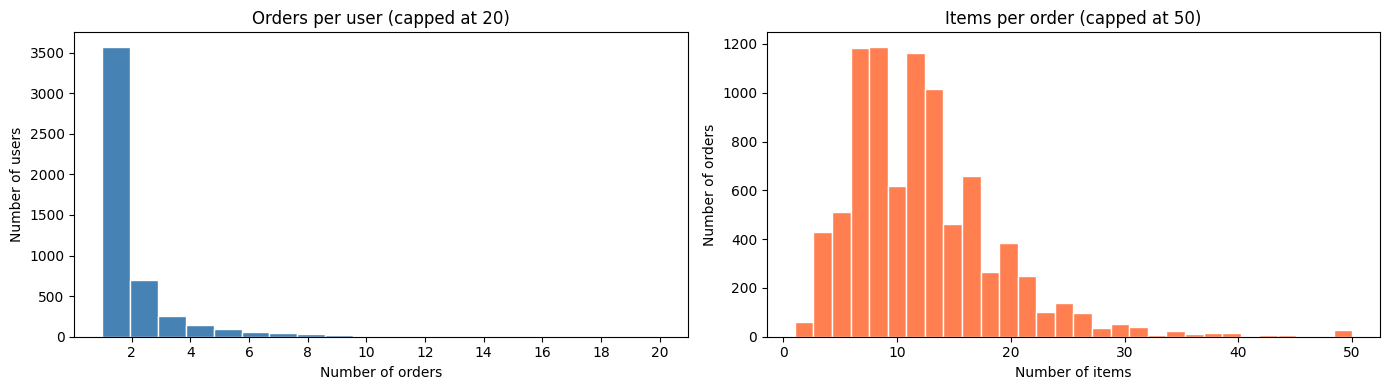

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Orders per user ---
orders_per_user = orders.groupby("user_id")["id"].count()

print("Orders per user:")
print(orders_per_user.describe().round(1).to_string())
print(f"\n  Users with only 1 order : {(orders_per_user == 1).sum():,}  ({(orders_per_user == 1).mean()*100:.1f}%)")
print(f"  Users with 2-5 orders   : {orders_per_user.between(2,5).sum():,}  ({orders_per_user.between(2,5).mean()*100:.1f}%)")
print(f"  Users with >5 orders    : {(orders_per_user > 5).sum():,}  ({(orders_per_user > 5).mean()*100:.1f}%)")

# --- Items per order ---
orders["n_items"] = orders["ordered_items"].apply(len)

print("\n\nItems per order:")
print(orders["n_items"].describe().round(1).to_string())

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Orders per user (capped at 20 for readability)
axes[0].hist(orders_per_user.clip(upper=20), bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Orders per user (capped at 20)")
axes[0].set_xlabel("Number of orders")
axes[0].set_ylabel("Number of users")
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(2))

# Items per order (capped at 50)
axes[1].hist(orders["n_items"].clip(upper=50), bins=30, color="coral", edgecolor="white")
axes[1].set_title("Items per order (capped at 50)")
axes[1].set_xlabel("Number of items")
axes[1].set_ylabel("Number of orders")

plt.tight_layout()
plt.show()


In [ ]:
#   PEDIDOS POR USUARIO
#71,7% de los usuarios solo ha comprado 1 vez (probloema de retencion?)
#23,8% ha comprado 2-5 veces
#4,5% ha comprado más de 5 veces

#   ITEMS POR PEDIDO
#pedidos media de 12,3 productos por pedido, minimo 1 producto y máximo 114

## 9. Product catalogue (inventory)

We explore the inventory dataset to understand:
- What **product categories** exist and how many products each has
- How **prices** are distributed
- Which **vendors/brands** are most represented


Product categories (top 15 by count):
---------------------------------------------
product_type
cleaning-products       160
tins-packaged-foods     125
snacks-confectionery    122
cooking-ingredients      73
pasta-rice-noodles       66
baby-toddler-food        62
condiments-dressings     52
cereal                   51
haircare                 50
biscuits-crackers        49
soft-drinks-mixers       48
baby-kids-toiletries     45
skincare                 44
cooking-sauces           43
dog-food                 42

  Total categories: 59


Top 15 vendors by number of products:
---------------------------------------------
vendor
biona            69
ecover           34
napolina         28
faithinnature    27
method           26
hiderfoods       24
greencuisine     24
various          23
ellaskitchen     18
febreze          17
heinz            17
cooksco          17
scrumbles        17
tommeetippee     16
bulldog          16

  Total vendors: 412


Price distribution (£):
------------------

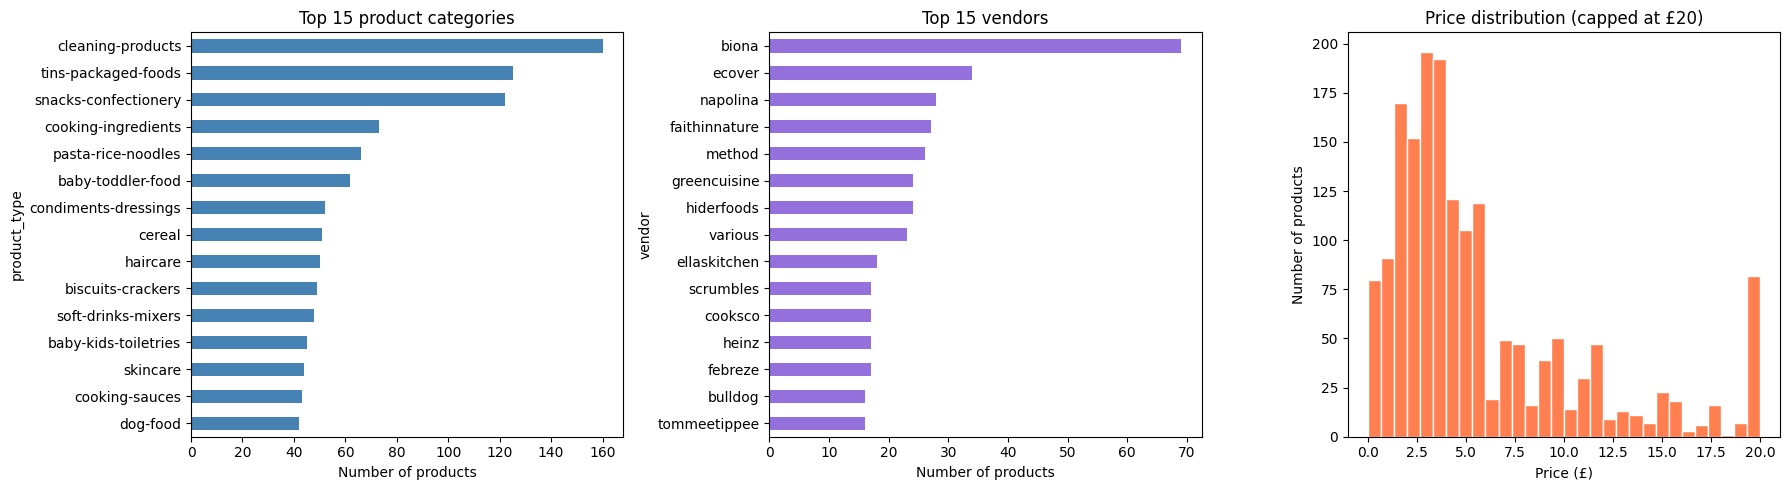

In [10]:
#  Product categories 
print("Product categories (top 15 by count):")
print("-" * 45)
cat_counts = inventory["product_type"].value_counts()
print(cat_counts.head(15).to_string())
print(f"\n  Total categories: {inventory['product_type'].nunique()}")

#  Vendors 
print("\n\nTop 15 vendors by number of products:")
print("-" * 45)
print(inventory["vendor"].value_counts().head(15).to_string())
print(f"\n  Total vendors: {inventory['vendor'].nunique()}")

#  Price distribution 
print("\n\nPrice distribution (£):")
print("-" * 35)
print(inventory["price"].describe().round(2).to_string())

# Plots 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top 15 categories
cat_counts.head(15).sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 15 product categories")
axes[0].set_xlabel("Number of products")

# Top 15 vendors
inventory["vendor"].value_counts().head(15).sort_values().plot(kind="barh", ax=axes[1], color="mediumpurple")
axes[1].set_title("Top 15 vendors")
axes[1].set_xlabel("Number of products")

# Price distribution (capped at £20)
axes[2].hist(inventory["price"].clip(upper=20), bins=30, color="coral", edgecolor="white")
axes[2].set_title("Price distribution (capped at £20)")
axes[2].set_xlabel("Price (£)")
axes[2].set_ylabel("Number of products")

plt.tight_layout()
plt.show()


In [ ]:
#59 categorías, las más grandes cleaning-products, tins-packaged-foods y snacks-confectionery
#marcas: 412 marcas, biona domina con 69 productos (especializada en productos orgánicos), various como vendedor: productos de marca blanca o sin marca definida?
#precios: la mediana £3.99 (barata), media de £6.31 bastante más alta, 16,6% de los productos cuesta más de £10

#price en 0? Productos gratis?

## 10. User profiles

We explore three dimensions of the user base:
- **Segments** — what commercial segments does the platform define?
- **Geography** — where in the UK are users located? (`user_nuts1` is a UK regional classification)
- **Cohorts** — when did users join? Is there growth over time?


User segments:
-----------------------------------
user_segment
Top Up         2643
Proposition    2340


Geographic distribution (user_nuts1):
-----------------------------------
user_nuts1
UKI    1318
UKJ     745
UKK     602
UKH     414
UKD     358
UKM     315
UKE     303
UKG     295
UKF     252
UKL     224
UKC     102
UKN       4


New users per month — total months: 24
  Avg new users/month : 208
  Peak month          : 2022-01 (688 users)


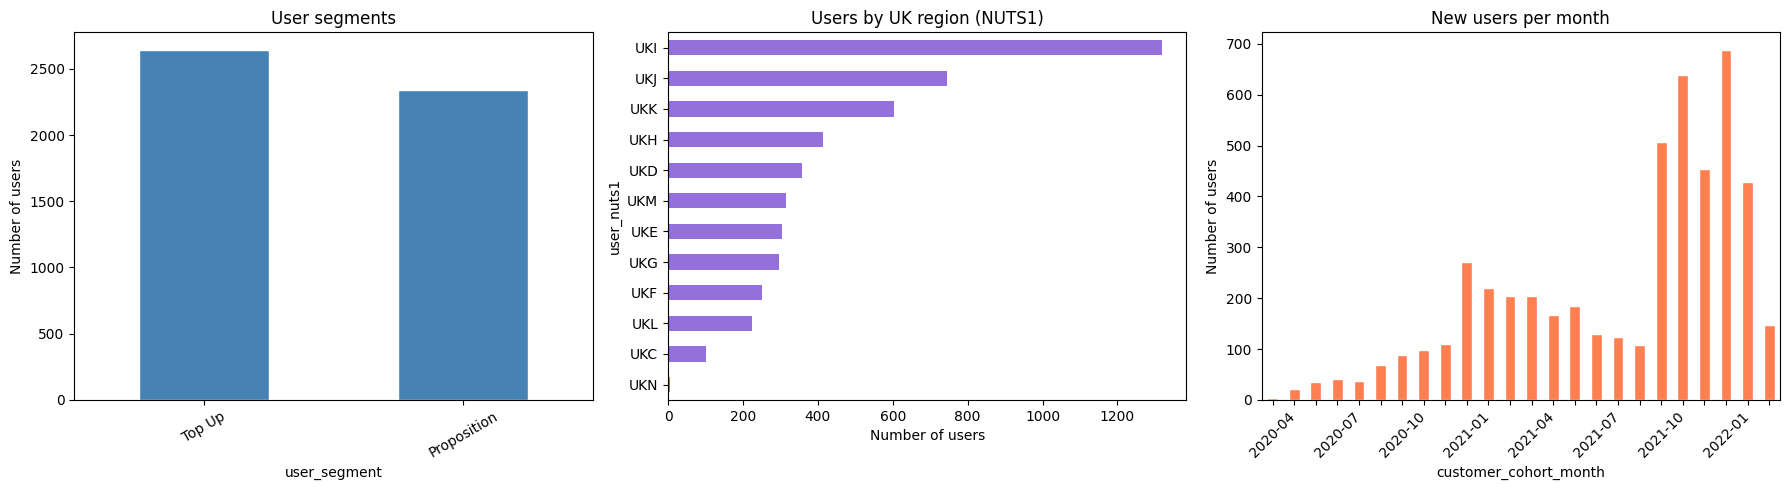

In [11]:
# --- User segments ---
print("User segments:")
print("-" * 35)
seg_counts = users["user_segment"].value_counts()
print(seg_counts.to_string())

# --- Geography ---
print("\n\nGeographic distribution (user_nuts1):")
print("-" * 35)
geo_counts = users["user_nuts1"].value_counts()
print(geo_counts.to_string())

# --- New users per month (cohort growth) ---
cohort = pd.to_datetime(users["customer_cohort_month"])
cohort_monthly = cohort.dt.to_period("M").value_counts().sort_index()

print(f"\n\nNew users per month — total months: {len(cohort_monthly)}")
print(f"  Avg new users/month : {cohort_monthly.mean():.0f}")
print(f"  Peak month          : {cohort_monthly.idxmax()} ({cohort_monthly.max()} users)")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Segments
seg_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("User segments")
axes[0].set_ylabel("Number of users")
axes[0].tick_params(axis="x", rotation=30)

# Geography
geo_counts.sort_values().plot(kind="barh", ax=axes[1], color="mediumpurple")
axes[1].set_title("Users by UK region (NUTS1)")
axes[1].set_xlabel("Number of users")

# Monthly cohorts
cohort_monthly.plot(kind="bar", ax=axes[2], color="coral", edgecolor="white")
axes[2].set_title("New users per month")
axes[2].set_ylabel("Number of users")
axes[2].tick_params(axis="x", rotation=45)
# Show every 3rd label to avoid clutter
for i, label in enumerate(axes[2].get_xticklabels()):
    if i % 3 != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
#2 segmentos: Proposition (primary shoppers) 2.340 usuariosy Top Up (complementary shoppers)2.643 usuarios
#división bastante equilibrada, gran parte usa plataforma de forma secundaria (productos más específicos), y otra gran parte como supermercado principal.

#geografía: Londres (UKI) domina con 1.318, y principalmente en el sur de Inglaterra con epicentro en Londres.

#crecimiento de usuaarios: empiezan con solo 3 usuarios en abril del 2020, media de 208 nuevos usuarios al mes, pico en enero de 2022 con 688 nuevos usuarios, y en marzo del 2022 hay 147 (por debajo de la media, está cortado a mitad de mes?)

## 11. Fixes

From the quick checks, we identified 4 issues to address:

| # | Dataset | Issue | Fix |
|---|---|---|---|
| 1 | `regulars` | 123 fully duplicated rows | Drop exact duplicates |
| 2 | `regulars` | Same `(user_id, variant_id)` marked multiple times | Keep only the most recent record per pair |
| 3 | `users` | `first_ordered_at` and `customer_cohort_month` stored as `object` instead of `datetime` | Convert to datetime |
| 4 | `users` | Household columns (`count_*`) have 93.5% nulls — unusable | Drop columns entirely |


In [12]:
# ── Fix 1 & 2: regulars ──────────────────────────────────────────────────────
print(f"regulars before: {len(regulars):,} rows")

# Fix 1: drop fully duplicated rows
regulars = regulars.drop_duplicates()
print(f"regulars after dropping exact duplicates: {len(regulars):,} rows")

# Fix 2: keep only the most recent record per (user_id, variant_id)
regulars = (
    regulars
    .sort_values("created_at", ascending=False)
    .drop_duplicates(subset=["user_id", "variant_id"])
    .sort_index()
    .reset_index(drop=True)
)
print(f"regulars after keeping latest per (user_id, variant_id): {len(regulars):,} rows")

# ── Fix 3: users — convert date columns to datetime ───────────────────────────
print(f"\nusers dtypes before fix:")
print(users[["first_ordered_at", "customer_cohort_month"]].dtypes.to_string())

users["first_ordered_at"] = pd.to_datetime(users["first_ordered_at"])
users["customer_cohort_month"] = pd.to_datetime(users["customer_cohort_month"])

print(f"\nusers dtypes after fix:")
print(users[["first_ordered_at", "customer_cohort_month"]].dtypes.to_string())

# ── Fix 4: users — drop household columns (93.5% null, unusable) ──────────────
household_cols = ["count_people", "count_adults", "count_children", "count_babies", "count_pets"]
users = users.drop(columns=household_cols)
print(f"\nusers columns after dropping household cols: {list(users.columns)}")

print("\n✓ All fixes applied.")


regulars before: 18,105 rows
regulars after dropping exact duplicates: 17,982 rows
regulars after keeping latest per (user_id, variant_id): 12,365 rows

users dtypes before fix:
first_ordered_at         object
customer_cohort_month    object

users dtypes after fix:
first_ordered_at         datetime64[ns]
customer_cohort_month    datetime64[ns]

users columns after dropping household cols: ['user_id', 'user_segment', 'user_nuts1', 'first_ordered_at', 'customer_cohort_month']

✓ All fixes applied.


In [ ]:
#fix 1: filas exactamente duplicadas en regulars: se eliminaron 123 filas
#fix 2: Duplicados por (user_id, variant_id) en regulars:se eliminaron 5.617 registros más antiguos, quedándose con el más reciente por cada par usuario-producto)
#fix 3: Tipos de fecha en users: first_ordered_at y customer_cohort_month pasaron de object (texto) a datetime64 para poder hacer operaciones de tiempo con ellas
#fix 4: Columnas de hogar en users: Se eliminaron count_people, count_adults, count_children, count_babies, count_pets, users pasa de 10 columnas a 5 columnas útiles: user_id, user_segment, user_nuts1, first_ordered_at, customer_cohort_month

## 12. Hypothesis 1: Do user segments reflect different buying behaviour?

The platform defines two segments: `Proposition` (primary shoppers) and `Top Up` (complementary shoppers).  

**Hypothesis:** Proposition users buy more frequently and place larger orders than Top Up users.  

── Orders per user by segment ──────────────────
               count  mean  std  min  25%  50%  75%   max
user_segment                                             
Proposition  2340.00  1.80 1.90 1.00 1.00 1.00 2.00 22.00
Top Up       2643.00  1.70 2.00 1.00 1.00 1.00 2.00 25.00

── Items per order by segment ──────────────────
               count  mean  std  min   25%   50%   75%    max
user_segment                                                 
Proposition  4177.00 15.70 6.80 2.00 11.00 14.00 18.00  71.00
Top Up       4596.00  9.30 5.30 1.00  6.00  8.00 11.00 114.00


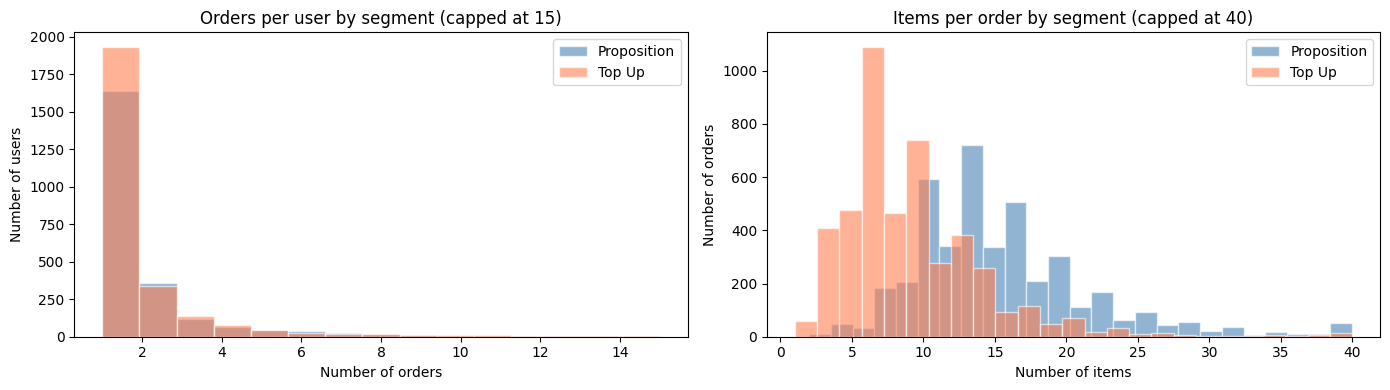

In [13]:
# Re-apply fixes to get clean versions
regulars_clean = (
    regulars.drop_duplicates()
    .sort_values("created_at", ascending=False)
    .drop_duplicates(subset=["user_id", "variant_id"])
    .reset_index(drop=True)
)
users_clean = users.copy()
users_clean["first_ordered_at"] = pd.to_datetime(users_clean["first_ordered_at"])
household_cols = ["count_people", "count_adults", "count_children", "count_babies", "count_pets"]
users_clean = users_clean.drop(columns=[c for c in household_cols if c in users_clean.columns])

orders["n_items"] = orders["ordered_items"].apply(len)

# Join orders with user segment
orders_with_segment = orders.merge(users_clean[["user_id", "user_segment"]], on="user_id", how="left")

# Orders per user per segment
orders_per_user_seg = (
    orders_with_segment.groupby(["user_id", "user_segment"])["id"]
    .count()
    .reset_index()
    .rename(columns={"id": "n_orders"})
)

# Items per order per segment
items_per_order_seg = orders_with_segment.groupby("user_segment")["n_items"].describe().round(1)

print("── Orders per user by segment ──────────────────")
print(orders_per_user_seg.groupby("user_segment")["n_orders"].describe().round(1).to_string())

print("\n── Items per order by segment ──────────────────")
print(items_per_order_seg.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for seg, color in zip(["Proposition", "Top Up"], ["steelblue", "coral"]):
    data = orders_per_user_seg[orders_per_user_seg["user_segment"] == seg]["n_orders"].clip(upper=15)
    axes[0].hist(data, bins=15, alpha=0.6, label=seg, color=color, edgecolor="white")
axes[0].set_title("Orders per user by segment (capped at 15)")
axes[0].set_xlabel("Number of orders")
axes[0].set_ylabel("Number of users")
axes[0].legend()

for seg, color in zip(["Proposition", "Top Up"], ["steelblue", "coral"]):
    data = orders_with_segment[orders_with_segment["user_segment"] == seg]["n_items"].clip(upper=40)
    axes[1].hist(data, bins=25, alpha=0.6, label=seg, color=color, edgecolor="white")
axes[1].set_title("Items per order by segment (capped at 40)")
axes[1].set_xlabel("Number of items")
axes[1].set_ylabel("Number of orders")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
#Conclusiones:

#Frecuencia de compra:los segmentos no se diferencian mucho en cuanto a frecuencia de compra.
# Ambos tienen ~71% de compradores únicos. Esto es raro porque cabría esperar que un Proposition volviera mucho
#más.

#Tamaño de la cesta: aquí sí que podemos ver diferencia. Los Proposition compran casi el doble de items por pedido que los Top Up.
#Esto tiene sentido; si usas esta plataforma como supermercado principal, llevas más cosas.

## 13. Hypothesis 2: Are "regular" products actually bought more?

Users can mark products as regular. Does that signal actually predict purchases?

We approach this from two angles:
- **Recall**: of all the items a user marked as regular, what fraction do they actually buy?
- **Precision**: of all the items a user buys, what fraction were marked as regular?


In [ ]:
#conclusiones:
#Recall de 58,9%: de todos los productos marcados como regular, el 58,9% acaba comprándolo en algun pedido. 
# #Más de la mitad de lo que dices que vas a comprar, acabas comprando.

#Precision del 23,3%: de todo lo que un usuario acaba comprando, el 23,3% acaba siendo regular. Casi 1 de cada 4 productos en la cesta es un regular.

#Lift de 47x: si eligieras productos al azar del catálogo, solo el 0,5% de lo que coges sería un regular. Pero en realidad, 23,3% de sus compras son regulares. es decir, 47 veces más de lo que se esperaría al azar.

## 14. Hypothesis 3: Do abandoned cart items eventually get purchased?

When a user adds items to their basket but doesn't buy them, does that signal future purchase intent?

**Hypothesis:** A meaningful fraction of abandoned items end up being bought by that user in a later order.  

If true, the abandoned cart is a useful behavioural signal — the user showed intent but something stopped them (price, timing, distraction).


In [ ]:
# Explode abandoned_carts to get one row per (user_id, variant_id)
carts_exploded = abandoned_carts.explode("variant_id")
carts_exploded["variant_id"] = carts_exploded["variant_id"].astype("int64")

# Unique (user_id, variant_id) pairs that were abandoned
abandoned_pairs = set(zip(carts_exploded["user_id"], carts_exploded["variant_id"]))

# Unique (user_id, variant_id) pairs that were purchased (all users, already computed)
all_purchased_pairs = set(zip(orders_exploded["user_id"], orders_exploded["variant_id"]))

# Overlap: items that were abandoned AND later purchased by the same user
abandoned_then_bought = abandoned_pairs & all_purchased_pairs

print(f"Unique (user, product) pairs abandoned : {len(abandoned_pairs):,}")
print(f"Unique (user, product) pairs purchased : {len(all_purchased_pairs):,}")
print(f"Abandoned items that were also bought  : {len(abandoned_then_bought):,}")

rate = len(abandoned_then_bought) / len(abandoned_pairs) * 100
print(f"\n→ {rate:.1f}% of abandoned items were eventually purchased by the same user")

# Baseline: what % of the catalog does a random user buy?
avg_purchased_per_user = orders_exploded.groupby("user_id")["variant_id"].nunique().mean()
baseline_cart = avg_purchased_per_user / inventory["variant_id"].nunique() * 100
lift_cart = rate / baseline_cart
print(f"\nBaseline — avg unique products bought / catalog : {baseline_cart:.1f}%")
print(f"Lift     — {lift_cart:.1f}x vs random")

# Extra: basket size comparison — abandoned vs purchased
avg_abandoned_size = carts_exploded.groupby("id")["variant_id"].count().mean()
avg_order_size = orders_exploded.groupby("id")["variant_id"].count().mean()

print(f"\nAvg items per abandoned cart : {avg_abandoned_size:.1f}")
print(f"Avg items per order          : {avg_order_size:.1f}")


In [ ]:
# Explode ordered_items to get one row per (user_id, variant_id) bought
orders_exploded = orders.explode("ordered_items").rename(columns={"ordered_items": "variant_id"})
orders_exploded["variant_id"] = orders_exploded["variant_id"].astype("int64")

# Only users who have regulars
users_with_regulars = set(regulars_clean["user_id"])
orders_regulars_users = orders_exploded[orders_exploded["user_id"].isin(users_with_regulars)]

# All unique (user_id, variant_id) pairs actually purchased by these users
purchased_pairs = set(zip(orders_regulars_users["user_id"], orders_regulars_users["variant_id"]))

# All unique (user_id, variant_id) pairs marked as regular
regular_pairs = set(zip(regulars_clean["user_id"], regulars_clean["variant_id"]))

# Overlap
both = purchased_pairs & regular_pairs

print(f"Users with regulars               : {len(users_with_regulars):,}")
print(f"Unique (user, product) pairs bought by those users : {len(purchased_pairs):,}")
print(f"Unique (user, product) regular pairs               : {len(regular_pairs):,}")
print(f"Pairs that are BOTH regular AND purchased           : {len(both):,}")

# Recall: of all regular pairs, how many were actually bought?
recall = len(both) / len(regular_pairs) * 100
print(f"\nRecall  — % of regular items that were bought  : {recall:.1f}%")

# Precision: of all purchased pairs (for users with regulars), how many were regular?
precision = len(both) / len(purchased_pairs) * 100
print(f"Precision — % of bought items that were regular : {precision:.1f}%")

# Baseline: what % of all inventory items are regular for those users?
inventory_size = inventory["variant_id"].nunique()
avg_regulars_per_user = regulars_clean.groupby("user_id")["variant_id"].count().mean()
baseline = avg_regulars_per_user / inventory_size * 100
print(f"\nBaseline — avg regulars per user / catalog size : {baseline:.1f}%")
print(f"  (avg {avg_regulars_per_user:.1f} regular items out of {inventory_size:,} products in catalog)")
print(f"\n→ Precision ({precision:.1f}%) vs baseline ({baseline:.1f}%) — {precision/baseline:.1f}x lift")


In [ ]:
#conclusiones:
#79% de los productos abandonados acaban siendo comprados por ese usuario en algun pedido posterior.
#Lift de 98,5x: si eliges al azar un producto del catálogo para ese usuario, solo habría un 0,8% de probabilidad de que lo compre, pero si está en su cesta abandonada, la probabilidad sube al 79,9%.

#Reflexión:
#Estamos mirando si producctos abandonados en algún momento acabó en algún pedido, pero no estamos teniendo en cuenta el orden temporal de cuándo sucede (puede que el usuario lo comprara antes de abandonarlo en el carrito, no después, osea que puede estar inflando el número)
#Lo que sí que podemos decir es que los productos en cestas abandonadas son productos que el usuario compra habitualmente.
#Las cestas abandonadas son menos de la mitad de tamaño que los pedidos reales, así que a lo mejor el usuario empieza a añadir items pero no termina de completar la compra.